<a href="https://colab.research.google.com/github/gonzaloangaut/NeuralNetworks/blob/main/Practicos/redes_neuronales_2023_practico_12_Angaut.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ajuste de modelos via cuadrados mínimos usando PyTorch

## Ejercicio 1)

Instale `pytorch` usando el comando de bash

In [ ]:
!pip3 install torch torchvision torchaudio torchviz

## Ejercicio 2)

**1)** Importe librerias `numpy`, `scipy` y `matplotlib`.

**2)** Importe librerias de `pytorch`.
Para ello, vea el colab `pytorch-tutorial-1-tensores.ipynb`.

In [ ]:
import numpy as np
import scipy as sp
import scipy.linalg as linalg
import matplotlib.pyplot as plt

In [ ]:
import torch
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda, Compose
from torchviz import make_dot
import torch.optim as optim

## Ejercicio 2)

Considere una secuencia de mediciones $(x_i,y_i)$ con $i=1,...,m$ de una variable independiente $x$ y una variable dependiente $y$.

Considere un modelo

$$
y = f(x,w) = \exp(-w_0 x)\sin(w_1x)
$$

donde $w=(w_0,w_1)$ es el vector de los parámetros del modelo.

**1)** Use `np.linspace` para generar un vector de 20 valores de $x$ en $[0,3]$.

**2)** Con $w=(0.5,4)$, use los valores de $x$ para generar un vector de 30 valores de $y$, i.e. un vector de componentes $y_i = f(x_i,w)$.

**3)** Genere valores experimentales *sintéticos* agregando ruido al vector $y$ generado en **2)**, agregandole números aleatorios obtenidos de una distribución normal de media $0$ y desviación estandard $0.1$.

**4)** Grafique los datos *experimentales* usando puntos.
Simultaneamente, grafique la curva *exacta*, interpolando sobre 300 puntos en el mismo rango.

In [ ]:
# 2.1)
x_vector = np.linspace(0, 3, 30)

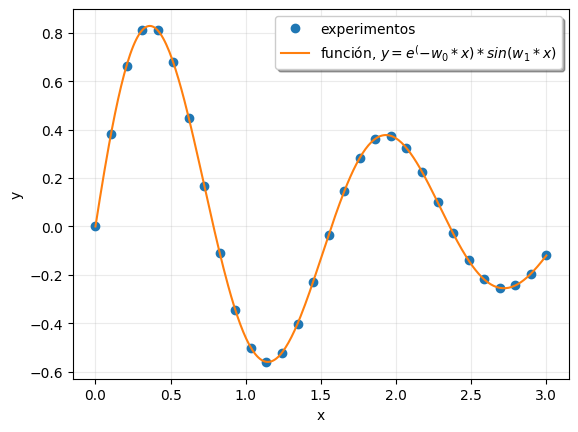

In [ ]:
# 2.2)

def f(x,w):
  return np.exp(-w[0]*x)*np.sin(w[1]*x)

w = np.array([0.5, 4])
y_vector = [f(x, w) for x in x_vector]

# vamos a graficar esto

plt.plot(x_vector, y_vector, 'o', label='experimentos') # grafico los puntos
xx = np.linspace(0, 3, 300)
#yy = [f(x, w) for x in xx]
yy = f(xx, w) # se hace así para que sea un array de numpy y no una lista
plt.plot(xx, yy, label='función, $y = e^(-w_0*x)*sin(w_1*x)$')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(framealpha=1, shadow=True)
plt.grid(alpha=0.25)
plt.show()

In [ ]:
# 2.3)

# ahora vamos a hacer lo mismo pero agregando ruido en los valores experimentales.
# para esto, vamos a sumar números aleatorios obtenidos de una distribución normal de media $0$ y desviación estandard $0.1$
# uso sigma * np.random.randn(...) + mu

sigma = 0.1
mu = 0
w = np.array([0.5, 4])
y_vector = [f(x, w) + sigma*np.random.randn()+mu for x in x_vector]

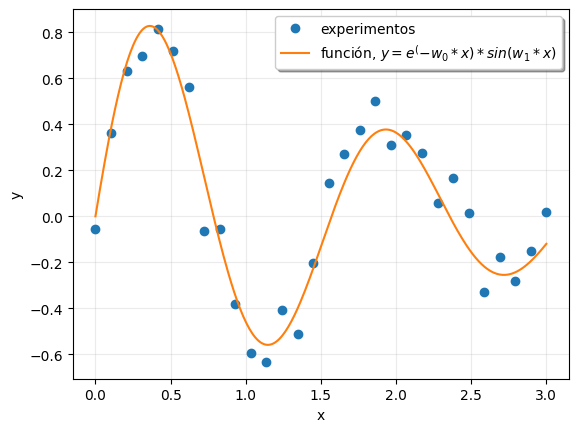

In [ ]:
# 2.4)

# vamos a graficar esto

plt.plot(x_vector, y_vector, 'o', label='experimentos') # grafico los puntos
xx = np.linspace(0, 3, 300)
#yy = [f(x, w) for x in xx]
yy = f(xx, w)
plt.plot(xx, yy, label='función, $y = e^(-w_0*x)*sin(w_1*x)$')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(framealpha=1, shadow=True)
plt.grid(alpha=0.25)
plt.show()

## Ejercicio 3)

El ajuste de un modelo por cuadrados mínimos, consiste en encontrar el vector de parámetros que minimiza la suma de los cuadrados de las diferencias entre los datos y las predicciones del modelo.
Más precisamente, consiste en minimizar

$$
E(w) = \sum_i (f(x_i,w)-y_i)^2
$$

con respecto a $w$.

**1)** Minimice $E(w)$ utilizando el algoritmo del descenso por el gradiente.
Implemente el algoritmo utilizando `pytorch`. Saque ventaja de la capacidad de `pytorch` de calcular gradientes de manera automática. Utilice un learning rate $\eta=0.001$ y como valores iniciales de $w$, los originales, pero levemente perturbados con un números aleatorios obtenidos de una distribución normal de media $1$ y desviación estandard $0.25$.

**2)** Grafique, utilizando los mismos 300 puntos de antes, la curva ajustada por el algoritmo anterior.

In [ ]:
# 3.1)

eta = 1e-3 # tambien suele llamar lr (learning rate)
num_epocas = 3000
#torch.manual_seed(42)

w_ini = [p*(1+0.25*np.random.normal()) for p in w] # le agregamos ruido al w

# convertimos los datos a tensores
w_torch = [torch.tensor([p], requires_grad=True, dtype=torch.float) for p in w_ini]
x_torch = torch.tensor(x_vector)
y_torch = torch.tensor(y_vector)

print(f"Inicial w_torch={[p.item() for p in w_torch]}") # imprimimos el w inicial
print(" ")

# Iteramos sobre épocas de entrenamiento
for epoca in range(num_epocas):

    # Calculamos las predicciones del modelo, el error y la función de pérdida.
    f_torch = torch.exp(-w_torch[0]*x_torch)*torch.sin(w_torch[1]*x_torch) # la función evaluada en los w_torch. no sirve np aca
    loss = ((f_torch-y_torch)**2).sum()

    # Ya no debemos calcular el gradiente de forma manual.
    # Basta con decirle a PyTorch que llame al método backward() del tensor del cual queremos calcular el gradiente.
    # En este caso, dicho tensor es "loss"; la función de pérdida.
    loss.backward()
    # backward ya directamente calcula el gradiente y lo guarda en .grad

    # Veamos las componentes del gradiente que obtuvimos en la presente época (lo hace antes de actualizar)
    if epoca%300==0:
      print(f"epoca={epoca} loss={loss.item()} w_torch={[p.item() for p in w_torch]}")

    # Actualizamos el valor de los parámetros del modelo, "w_torch" en este caso.
    # Para ello tenemos que desactivar el cálculo automático de gradientes. (esto es algo de pytorch)
    with torch.no_grad():
        for p in w_torch:
            p -= eta * p.grad # le resto lo que debo restarle a cada w en w_torch

    # PyTorch no resetea a cero los valores de las componentes del gradiente, sino que procede de manera acumulativa, ya que es conveniente por diferentes razones.
    # Por ende, tenemos que decirle explícitamente que resetee los valores a cero.
    for p in w_torch:
        p.grad.zero_()

# Imprimimos los valores ajustados
print("")
print(f"w_pred={[p.item() for p in w_torch]}")
print(f"w_exacta={w}")

Inicial w_torch=[0.5823130011558533, 4.660327911376953]
 
epoca=0 loss=2.076592627504289 w_torch=[0.5823130011558533, 4.660327911376953]
epoca=300 loss=0.31269725168357765 w_torch=[0.5002915859222412, 4.075614929199219]
epoca=600 loss=0.3046679843942208 w_torch=[0.4806310534477234, 4.045749187469482]
epoca=900 loss=0.3046624604544981 w_torch=[0.48026278614997864, 4.044893741607666]
epoca=1200 loss=0.3046624591237792 w_torch=[0.4802580773830414, 4.044889450073242]
epoca=1500 loss=0.3046624591237792 w_torch=[0.4802580773830414, 4.044889450073242]
epoca=1800 loss=0.3046624591237792 w_torch=[0.4802580773830414, 4.044889450073242]
epoca=2100 loss=0.3046624591237792 w_torch=[0.4802580773830414, 4.044889450073242]
epoca=2400 loss=0.3046624591237792 w_torch=[0.4802580773830414, 4.044889450073242]
epoca=2700 loss=0.3046624591237792 w_torch=[0.4802580773830414, 4.044889450073242]

w_pred=[0.4802580773830414, 4.044889450073242]
w_exacta=[0.5 4. ]


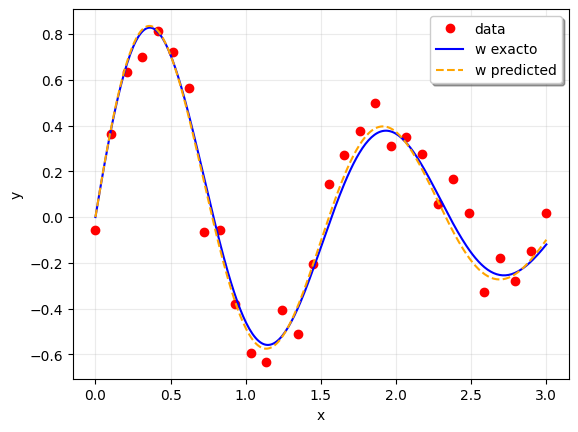

In [ ]:
# 3.2)

# ahora vamos a graficar lo mismo de antes pero vamos a añadir la función con el w predicted
# para eso debemos convertir el w_torch en elemento de numpy

w_pred = [p.item() for p in w_torch]

plt.plot(x_vector, y_vector, 'o', label='data', c='red') # grafico los puntos
xx = np.linspace(0, 3, 300)
#yy = [f(x, w) for x in xx]
yy = f(xx, w)
#yy_pred = [f(x, w_pred) for x in xx]
yy_pred = f(xx, w_pred)
plt.plot(xx, yy, label='w exacto', linestyle='-', c='blue')
plt.plot(xx, yy_pred, label='w predicted', linestyle='--', c='orange')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(framealpha=1, shadow=True)
plt.grid(alpha=0.25)
plt.show()

## Ejercicio 4)

**1)** Repita el ejercicio anterior, pero ahora ajustando el modelo

$$
f(x,w) = \exp(-w_0x+w_2)\sin(w_1x+w_3)
$$

i.e. un modelo con dos parámetros ajustables extra.

**2)** Calcule el error cuadratico medio de ambos modelos, sobre los 30 puntos de entrenamiento y sobre los 300 puntos del la curva exacta.

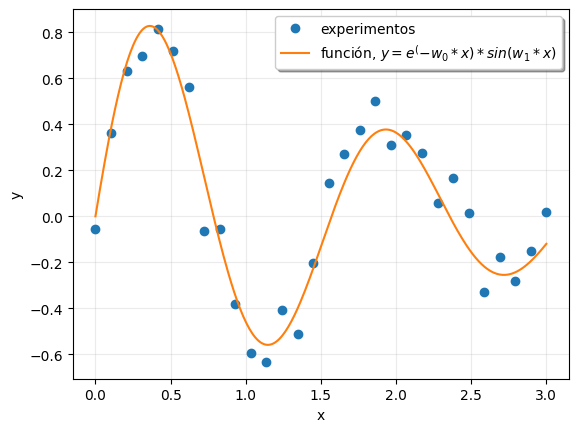

In [ ]:
# 4.1)
"""
Vamos a hacer lo mismo pero ahora agregando 2 parametros que si los hacemos 0 nos da la misma funcion que antes
"""
# vamos a usar los mismos valores de x_vector e y_vector (que serían los datos)

def f_2(x,w):
  return np.exp(-w[0]*x+w[2])*np.sin(w[1]*x+w[3])

w_2 = np.array([0.5, 4, 0, 0]) # agregamos 2 ceros como parámetros, para usar la misma función que antes

# vamos a graficar esto, es la misma gráfica que en el 2.4

plt.plot(x_vector, y_vector, 'o', label='experimentos') # grafico los puntos
xx = np.linspace(0, 3, 300)
#yy_2 = [f_2(x, w_2) for x in xx]
yy_2 = f_2(xx, w_2)
plt.plot(xx, yy, label='función, $y = e^(-w_0*x)*sin(w_1*x)$')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(framealpha=1, shadow=True)
plt.grid(alpha=0.25)
plt.show()

In [ ]:
# ahora vamos a hacer lo mismo que hicimos en el 3 pero para este modelo (es todo lo mismo, por eso saco los comentarios)

eta = 1e-3
num_epocas = 3000

w_ini = [p*(1+0.25*np.random.normal()) for p in w] # le agregamos ruido al w, debemos cambiar los valores de 0 para esto

w_torch = [torch.tensor([p], requires_grad=True, dtype=torch.float) for p in w_ini+[0.01,0.01]]
x_torch = torch.tensor(x_vector)
y_torch = torch.tensor(y_vector)

print(f"Inicial w_torch={[p.item() for p in w_torch]}")
print(" ")

for epoca in range(num_epocas):

    f_torch = torch.exp(-w_torch[0]*x_torch+w_torch[2])*torch.sin(w_torch[1]*x_torch+w_torch[3]) # acá hay que poner el modelo nuevo
    loss = ((f_torch-y_torch)**2).sum()

    loss.backward()

    if epoca%300==0:
      print(f"epoca={epoca} loss={loss.item()} w_torch={[p.item() for p in w_torch]}")

    with torch.no_grad():
        for p in w_torch:
            p -= eta * p.grad

    for p in w_torch:
        p.grad.zero_()

print("")
print(f"w_pred={[p.item() for p in w_torch]}")
print(f"w_exacta={w_2}")

Inicial w_torch=[0.33981454372406006, 4.192702770233154, 0.009999999776482582, 0.009999999776482582]
 
epoca=0 loss=0.6558808223663828 w_torch=[0.33981454372406006, 4.192702770233154, 0.009999999776482582, 0.009999999776482582]
epoca=300 loss=0.30367029629051023 w_torch=[0.4551263153553009, 4.079148769378662, -0.03145923838019371, -0.042973000556230545]
epoca=600 loss=0.3021048559565366 w_torch=[0.46587899327278137, 4.0699920654296875, -0.01868174597620964, -0.03429560363292694]
epoca=900 loss=0.301854950025507 w_torch=[0.4706322252750397, 4.0671586990356445, -0.012960364110767841, -0.031657081097364426]
epoca=1200 loss=0.30181016933527005 w_torch=[0.4728071987628937, 4.066380023956299, -0.010322634130716324, -0.031013989821076393]
epoca=1500 loss=0.30180084983684063 w_torch=[0.4738347828388214, 4.066244602203369, -0.009062269702553749, -0.030952516943216324]
epoca=1800 loss=0.3017986290743374 w_torch=[0.47433605790138245, 4.066244602203369, -0.008441069163382053, -0.031016206368803978

[0.4748116135597229, 4.066340446472168, -0.007845472544431686, -0.03116370365023613]


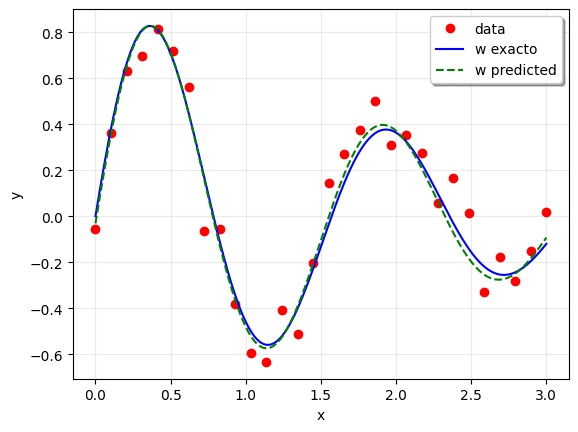

In [ ]:
# ahora grafiquemos para este modelo

w_pred_2 = [p.item() for p in w_torch]
print(w_pred_2)

plt.plot(x_vector, y_vector, 'o', label='data', c='red') # grafico los puntos
xx = np.linspace(0, 3, 300)
#yy_pred_2 = [f_2(x, w_pred_2) for x in xx]
yy_pred_2 = f_2(xx, w_pred_2)
plt.plot(xx, yy, label='w exacto', linestyle='-', c='blue')
plt.plot(xx, yy_pred_2, label='w predicted', linestyle='--', c='green')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(framealpha=1, shadow=True)
plt.grid(alpha=0.25)
plt.show()

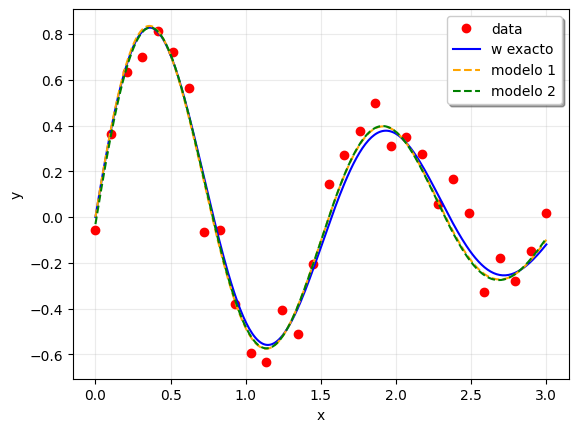

In [ ]:
# por último grafiquemos los 2 modelos juntos
print()
plt.plot(x_vector, y_vector, 'o', label='data', c='red') # grafico los puntos
plt.plot(xx, yy, label='w exacto', linestyle='-', c='blue')
plt.plot(xx, yy_pred, label='modelo 1', linestyle='--', c='orange')
plt.plot(xx, yy_pred_2, label='modelo 2', linestyle='--', c='green')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(framealpha=1, shadow=True)
plt.grid(alpha=0.25)
plt.show()

In [ ]:
# veamos ahora los errores cuadraticos medios de ambos modelos

error_1 = ((yy_pred-yy)**2).sum()
error_2 = ((yy_pred_2-yy)**2).sum()
print(f"El error cuadrático medio con respecto a la curva para el primer modelo es:{error_1}, mientras que para el 2do:{error_2}")

El error cuadrático medio con respecto a la curva para el primer modelo es:0.13629897624435217, mientras que para el 2do:0.15960594064400868


In [ ]:
yy_pred_data = f(x_vector, w_pred)
yy_pred_data_2 = f_2(x_vector, w_pred_2)

error_1_data = ((yy_pred_data-y_vector)**2).sum()
error_2_data = ((yy_pred_data_2-y_vector)**2).sum()
print(f"El error cuadrático medio con respecto a los datos para el primer modelo es:{error_1_data}, mientras que para el 2do:{error_2_data}")

El error cuadrático medio con respecto a los datos para el primer modelo es:0.30466245912377915, mientras que para el 2do:0.3017978402788474
